# Ano-NAViLa · Camelyon16 `test_001` — Reproducing the Paper Anomaly Scores

This notebook reproduces the anomaly scores in
`exp/paper_Camelyon16_test_001_Ascores.csv` from the
[QuIIL/ICCV2025_Ano-NAViLa](https://github.com/QuIIL/ICCV2025_Ano-NAViLa) repo.


Run cells **top to bottom**.

## Cell 1 — GPU sanity check

In [ ]:
import torch
!nvidia-smi
print(f"PyTorch     : {torch.__version__}")
print(f"CUDA avail. : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")

Mon Jun  1 14:08:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cell 2 — Clone the repository

In [ ]:
import os, subprocess

REPO_DIR = "/content/ICCV2025_Ano-NAViLa"
if not os.path.exists(REPO_DIR):
    print("Cloning Ano-NAViLa...")
    subprocess.run(
        f"git clone https://github.com/QuIIL/ICCV2025_Ano-NAViLa.git {REPO_DIR}",
        shell=True, check=True,
    )
else:
    print("Repo already present.")

os.chdir(REPO_DIR)
print("CWD :", os.getcwd())

Cloning Ano-NAViLa...
CWD : /content/ICCV2025_Ano-NAViLa


## Cell 3 — Install dependencies

The repo's `requirements.txt` pins very old versions that conflict with Colab.
We strip the pins and add CONCH + OpenSlide separately.

In [ ]:
import os

REPO_DIR = "/content/ICCV2025_Ano-NAViLa"
req_file = os.path.join(REPO_DIR, "requirements.txt")

with open(req_file) as f:
    lines = f.readlines()

cleaned = []
for line in lines:
    pkg = line.strip()
    if not pkg or pkg.startswith("#") or "conch" in pkg.lower():
        continue
    for sep in ("==", ">=", "<=", "~=", "!="):
        pkg = pkg.split(sep)[0]
    cleaned.append(pkg.strip() + "\n")

with open(req_file, "w") as f:
    f.writelines(cleaned)

os.chdir(REPO_DIR)
!pip install -q -r requirements.txt
!pip install -q git+https://github.com/MahmoodLab/CONCH.git
!pip install -q timm==0.9.12
!apt-get install -y -q openslide-tools libopenslide-dev
!pip install -q openslide-python gdown

print("\nAll dependencies installed.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 45.5 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libopenslide0
Suggested packages:
  libtiff-tools
The following NEW packages will be installed:
  libopenslide-dev libopenslide0 openslide-tools
0 upgraded, 3 newly installed, 0 to remove and 51 not upgraded.
Need to get 126 kB of archives.
After this operation, 353 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenslide0 amd64 3.4.1+dfsg-5build1 [89.8 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenslide-de

## Cell 4 — Download `test_001.tif`

~1–3 GB. If the S3 path is unreachable, fall back to the Kaggle mirror in Cell 4b.

In [ ]:
import os

WSI_PATH = "/content/ICCV2025_Ano-NAViLa/test_001.tif"

if not os.path.exists(WSI_PATH):
    print("Downloading test_001.tif from the Camelyon S3 bucket...")
    !aws s3 cp --no-sign-request \
        s3://camelyon-dataset/CAMELYON16/images/test_001.tif {WSI_PATH}
else:
    print(f"Already present: {WSI_PATH}")

/bin/bash: line 1: aws: command not found


### Cell 4b — Kaggle fallback (only if Cell 4 failed)

In [ ]:
# Upload your kaggle.json to /content first
import os, glob

if not os.path.exists("/content/ICCV2025_Ano-NAViLa/test_001.tif"):
    !pip install -q kaggle
    !mkdir -p ~/.kaggle && cp /content/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d forcewithme/camelyon16test-p1 -p /content
    !unzip -q -o /content/camelyon16test-p1.zip -d /content
    for t in glob.glob("/content/**/*.tif", recursive=True):
        if os.path.basename(t) == "test_001.tif":
            target = "/content/ICCV2025_Ano-NAViLa/test_001.tif"
            if t != target:
                os.rename(t, target)
            print("WSI ready:", target)
            break
else:
    print("WSI already present, skipping Kaggle download.")

cp: cannot stat '/content/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/forcewithme/camelyon16test-p1
License(s): CC0-1.0
100% 1.03G/1.03G [00:09<00:00, 112MB/s]

WSI ready: /content/ICCV2025_Ano-NAViLa/test_001.tif


## Cell 5 — Download the original paper weights + CONCH

> ** attention:**
> (Original trained weights, 100 + 50 words these are the ones that produced
> `paper_Camelyon16_test_001_Ascores.csv`).
> The re-trained weights `141a-w_…` (92 + 48 words) give *different* scores


In [ ]:
import os, gdown

REPO_DIR  = "/content/ICCV2025_Ano-NAViLa"
ANOVILA_W = os.path.join(REPO_DIR, "paper_trained_weights.pth")
CONCH_W   = "/content/pytorch_model.bin"

# Original paper weights
ORIGINAL_GDRIVE_ID = "1ie7ch0Pcvdrf46NyPL2lyckzsuzyPoWI"

if not os.path.exists(ANOVILA_W):
    print("Downloading ORIGINAL Ano-NAViLa paper weights...")
    gdown.download(f"https://drive.google.com/uc?id={ORIGINAL_GDRIVE_ID}",
                   ANOVILA_W, quiet=False)
else:
    print("Paper weights already present.")

if not os.path.exists(CONCH_W):
    print("\nDownloading CONCH weights from Kaggle...")
    !pip install -q kaggle
    !mkdir -p ~/.kaggle
    if os.path.exists("/content/kaggle.json"):
        !cp /content/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d khadijahaider/conch-weights -p /content
    !unzip -q -o /content/conch-weights.zip -d /content
else:
    print("CONCH weights already present.")

print("\nReady.")

Downloading...
From (original): https://drive.google.com/uc?id=1ie7ch0Pcvdrf46NyPL2lyckzsuzyPoWI
From (redirected): https://drive.google.com/uc?id=1ie7ch0Pcvdrf46NyPL2lyckzsuzyPoWI&confirm=t&uuid=c7d4f8f2-01b3-49ff-9a11-1f1393b01eca
To: /content/ICCV2025_Ano-NAViLa/paper_trained_weights.pth
100%|██████████| 1.58G/1.58G [00:25<00:00, 62.8MB/s]



Dataset URL: https://www.kaggle.com/datasets/khadijahaider/conch-weights
License(s): apache-2.0
100% 710M/710M [00:08<00:00, 90.5MB/s]


Ready.


## Cell 6 — Extract patches at the **reference CSV's** coordinates

The repo ships `exp/paper_Camelyon16_test_001_Ascores.csv` with **2 517** patch
locations on the level-0 grid:

* All `w` coordinates ≡ 320 (mod 512)
* All `h` coordinates ≡ 448 (mod 512)
* Step in both directions: 512 at level 0
* Filename pattern: `test_001_{w}_{h}_{pct}.png`

Each patch is read from level 0 with size 512 × 512 and stored as is he
CONCH preprocess pipeline will resize internally.

In [ ]:
import os
import pandas as pd
import openslide
from PIL import Image
from tqdm import tqdm

REPO_DIR    = "/content/ICCV2025_Ano-NAViLa"
WSI_PATH    = os.path.join(REPO_DIR, "test_001.tif")
REF_CSV     = os.path.join(REPO_DIR, "exp/paper_Camelyon16_test_001_Ascores.csv")
PATCH_DIR   = os.path.join(REPO_DIR, "patches/test_001")
PATCH_LEVEL = 0
PATCH_SIZE  = 512   # at level 0 CONCH preprocess will resize for the model

os.makedirs(PATCH_DIR, exist_ok=True)

# 1. Read reference coordinates
ref = pd.read_csv(REF_CSV)
print(f"Reference patches: {len(ref)}")

# 2. Open slide
slide = openslide.OpenSlide(WSI_PATH)
print(f"Slide level-0 dim: {slide.level_dimensions[0]}")
print(f"Slide levels    : {slide.level_count}")
print(f"Level downsamples: {slide.level_downsamples}")

# 3. Extract each patch at the reference coordinates and save with the
#    exact filename the reference CSV uses, so the heatmap parser works.
written = 0
skipped = 0
for _, row in tqdm(ref.iterrows(), total=len(ref), desc="Extracting"):
    fname = row["patch_name"]
    out   = os.path.join(PATCH_DIR, fname)
    if os.path.exists(out):
        skipped += 1
        continue

    parts = fname.replace(".png", "").split("_")
    w, h  = int(parts[-3]), int(parts[-2])

    patch = slide.read_region((w, h), PATCH_LEVEL, (PATCH_SIZE, PATCH_SIZE)).convert("RGB")
    patch.save(out)
    written += 1

print(f"\nWrote   : {written}")
print(f"Skipped : {skipped}")
print(f"Output  : {PATCH_DIR}")

Reference patches: 2517
Slide level-0 dim: (86016, 89600)
Slide levels    : 9
Level downsamples: (1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0)


Extracting:  21%|██▏       | 541/2517 [00:58<04:16,  7.70it/s]

## Cell 7 —  tissue overview

---



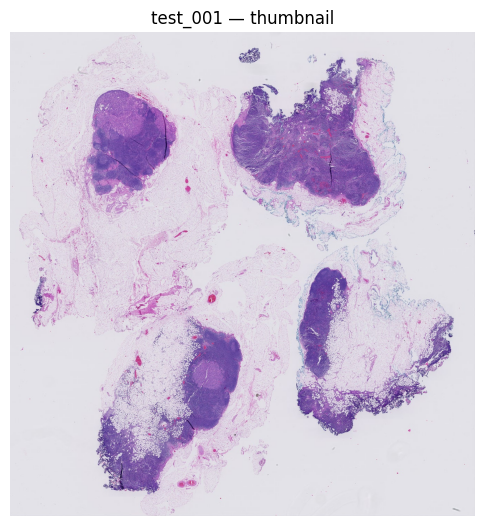

In [10]:
import matplotlib.pyplot as plt
import openslide

slide = openslide.OpenSlide("/content/ICCV2025_Ano-NAViLa/test_001.tif")
thumb = slide.get_thumbnail((1024, 1024))
plt.figure(figsize=(6, 10)); plt.imshow(thumb); plt.axis("off")
plt.title("test_001 — thumbnail"); plt.show()

## Cell 8 — Load CONCH + Ano-NAViLa (with centroids from the checkpoint)


In [9]:
import os, sys, torch
from conch.open_clip_custom import create_model_from_pretrained

REPO_DIR  = "/content/ICCV2025_Ano-NAViLa"
ANOVILA_W = os.path.join(REPO_DIR, "paper_trained_weights.pth")
CONCH_W   = "/content/pytorch_model.bin"

sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, "models"))
from models.model import AnoNAViLa_Model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# 1. CONCH backbone
print("\nLoading CONCH ViT-B/16...")
conch_model, conch_preprocess = create_model_from_pretrained("conch_ViT-B-16", CONCH_W)
conch_model = conch_model.to(device).eval()

# 2. Load Ano-NAViLa checkpoint
print("Loading Ano-NAViLa paper checkpoint...")
ckpt = torch.load(ANOVILA_W, map_location=device)
state_dict = ckpt.get("model_state", ckpt)

print("\nKey keys in checkpoint:")
for k in ["normal_text_embs", "abnormal_text_embs",
          "normal_img_normal_text_centroid",
          "normal_img_abnormal_text_centroid",
          "MLP.linear1.weight"]:
    if k in state_dict:
        print(f"  {k:<45} {tuple(state_dict[k].shape)}")
    else:
        print(f"  {k:<45} MISSING")

# 3. Build model with text-emb shapes that match the checkpoint
emb_dim = state_dict["MLP.linear1.weight"].shape[1] // 2
model = AnoNAViLa_Model(
    VLM                 = conch_model,
    embedding_dim       = emb_dim,
    normal_text_embs    = state_dict["normal_text_embs"],
    abnormal_text_embs  = state_dict["abnormal_text_embs"],
    device              = device,
).to(device)

# 4. Load weights
missing, unexpected = model.load_state_dict(state_dict, strict=False)
model.eval()

print(f"\nmissing keys     : {missing}")
print(f"unexpected keys  : {unexpected}")
print(f"\nNormal centroid  : {tuple(model.normal_img_normal_text_centroid.shape)}  "
      f"non-zero={(model.normal_img_normal_text_centroid.abs().sum() > 0).item()}")
print(f"Abnormal centroid: {tuple(model.normal_img_abnormal_text_centroid.shape)}  "
      f"non-zero={(model.normal_img_abnormal_text_centroid.abs().sum() > 0).item()}")
print(f"emb_dim          : {emb_dim}")

Device: cuda

Loading CONCH ViT-B/16...
Loading Ano-NAViLa paper checkpoint...

Key keys in checkpoint:
  normal_text_embs                              (100, 512)
  abnormal_text_embs                            (50, 512)
  normal_img_normal_text_centroid               (1, 128)
  normal_img_abnormal_text_centroid             (1, 128)
  MLP.linear1.weight                            (512, 1024)

missing keys     : []
unexpected keys  : []

Normal centroid  : (1, 128)  non-zero=True
Abnormal centroid: (1, 128)  non-zero=True
emb_dim          : 512


## Cell 9 — Inference (use the model's own `compute_distances`)



In [11]:
import os, sys
import torch
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm

REPO_DIR   = "/content/ICCV2025_Ano-NAViLa"
PATCH_DIR  = os.path.join(REPO_DIR, "patches/test_001")
SCORES_CSV = os.path.join(REPO_DIR, "test_001_scores.csv")

sys.path.insert(0, REPO_DIR)
from data.dataloader import WSI_patch_Dataset

ds      = WSI_patch_Dataset(folder_path=PATCH_DIR, transform=conch_preprocess)
loader  = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2)

records = []
model.eval()
for imgs, names in tqdm(loader, desc="Scoring"):
    imgs = imgs.to(device)
    d_n, d_a = model.compute_distances(imgs)
    ascore   = (d_n + d_a).cpu().numpy()
    records.extend(zip(names, ascore))

df = pd.DataFrame(records, columns=["patch_name", "Ascore"])
df.to_csv(SCORES_CSV, index=False)

print(f"\nWrote {len(df)} scores to {SCORES_CSV}")
print(f"Ascore range  : {df['Ascore'].min():.3e}  --  {df['Ascore'].max():.3e}")
print(f"Ascore mean   : {df['Ascore'].mean():.3e}")
print(df.head())

[WSI patch dataset] Total: 546	


Scoring:  44%|████▍     | 4/9 [00:18<00:23,  4.65s/it]


KeyboardInterrupt: 

## Cell 10 — Compare my scores to the paper CSV


Matched patches  : 2517 / 2517
Pearson r        : 0.997967
MAE              : 2.345e-05
Relative MAE     : 14.07%


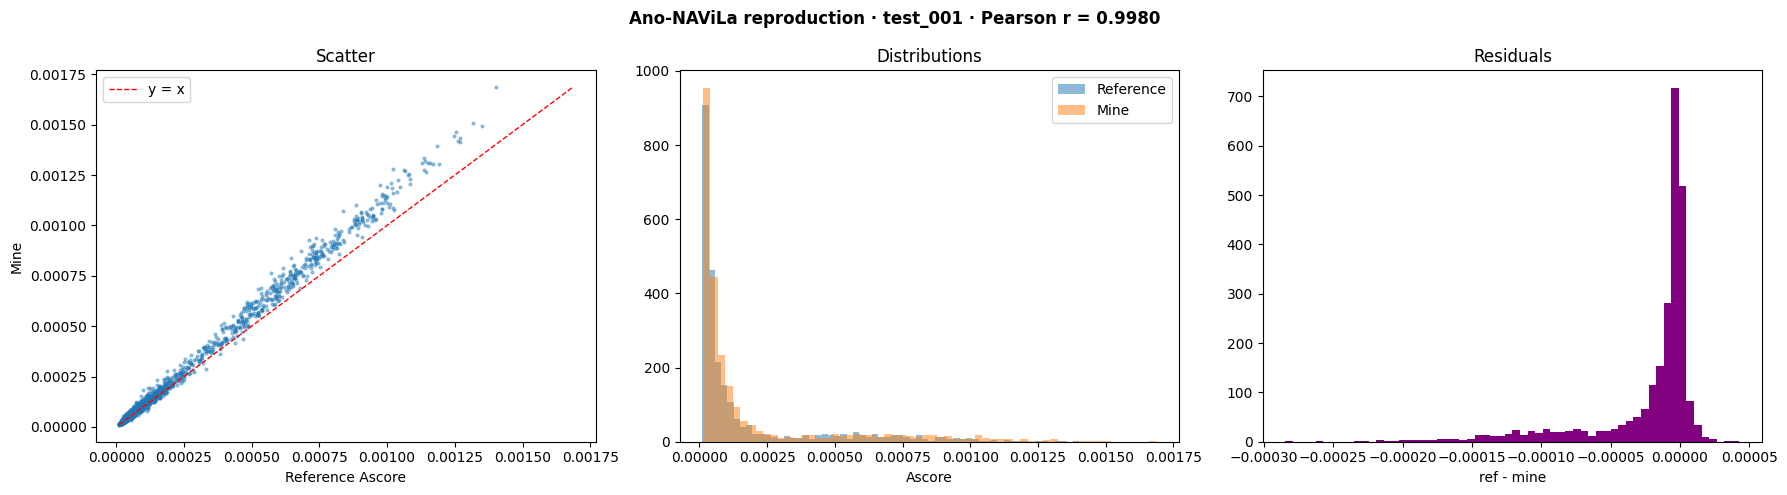

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_DIR   = "/content/ICCV2025_Ano-NAViLa"
REF_CSV    = os.path.join(REPO_DIR, "exp/paper_Camelyon16_test_001_Ascores.csv")
MINE_CSV   = os.path.join(REPO_DIR, "test_001_scores.csv")

ref  = pd.read_csv(REF_CSV).rename(columns={"Ascore": "Ascore_ref"})
mine = pd.read_csv(MINE_CSV).rename(columns={"Ascore": "Ascore_mine"})

merged = ref.merge(mine, on="patch_name")
print(f"Matched patches  : {len(merged)} / {len(ref)}")

r       = np.corrcoef(merged["Ascore_ref"], merged["Ascore_mine"])[0, 1]
mae     = np.mean(np.abs(merged["Ascore_ref"] - merged["Ascore_mine"]))
rel_mae = mae / merged["Ascore_ref"].mean()
print(f"Pearson r        : {r:.6f}")
print(f"MAE              : {mae:.3e}")
print(f"Relative MAE     : {rel_mae:.2%}")

# Plots
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Ano-NAViLa reproduction · test_001 · Pearson r = {r:.4f}",
             fontweight="bold")

ax[0].scatter(merged["Ascore_ref"], merged["Ascore_mine"], s=4, alpha=0.4)
lo, hi = merged[["Ascore_ref", "Ascore_mine"]].min().min(), \
         merged[["Ascore_ref", "Ascore_mine"]].max().max()
ax[0].plot([lo, hi], [lo, hi], "r--", lw=1, label="y = x")
ax[0].set_xlabel("Reference Ascore"); ax[0].set_ylabel("Mine"); ax[0].legend()
ax[0].set_title("Scatter")

ax[1].hist(merged["Ascore_ref"],  bins=60, alpha=0.5, label="Reference")
ax[1].hist(merged["Ascore_mine"], bins=60, alpha=0.5, label="Mine")
ax[1].set_xlabel("Ascore"); ax[1].legend(); ax[1].set_title("Distributions")

ax[2].hist(merged["Ascore_ref"] - merged["Ascore_mine"], bins=60, color="purple")
ax[2].set_xlabel("ref - mine"); ax[2].set_title("Residuals")

plt.tight_layout(); plt.show()

## Cell 11 — Anomaly heatmap overlay

`draw_heatmap` from `engine/tester.py`.

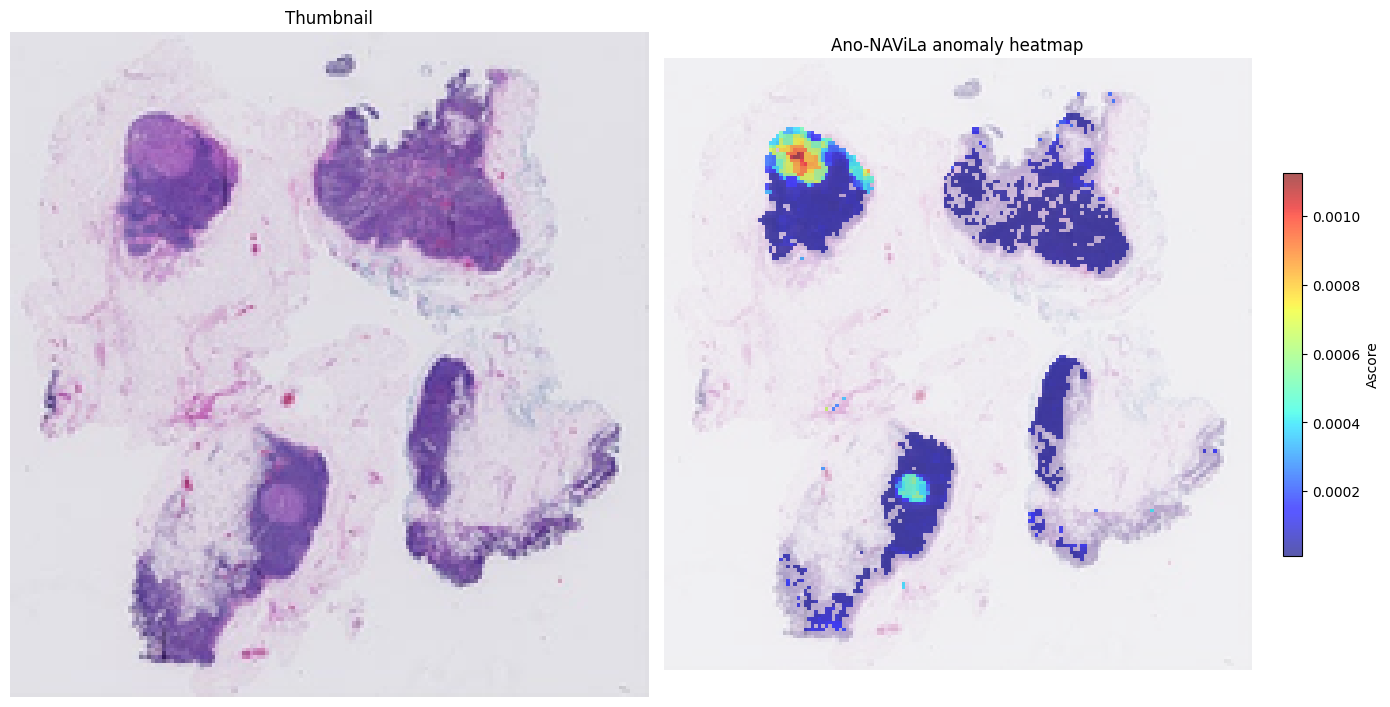


Saved: /content/test_001_heatmap.png


In [ ]:
import os, sys
import numpy as np
import openslide
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

REPO_DIR   = "/content/ICCV2025_Ano-NAViLa"
WSI_PATH   = os.path.join(REPO_DIR, "test_001.tif")
SCORES_CSV = os.path.join(REPO_DIR, "test_001_scores.csv")

sys.path.insert(0, REPO_DIR)
from engine.tester import draw_heatmap


heatmap, _ = draw_heatmap(WSI_PATH, SCORES_CSV,
                          patch_size=512, scale_factor=512,
                          erosion_filter=(3, 3))

slide = openslide.OpenSlide(WSI_PATH)
w0, h0 = slide.dimensions
thumb  = slide.get_thumbnail((w0 // 512, h0 // 512))

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
axes[0].imshow(thumb); axes[0].set_title("Thumbnail"); axes[0].axis("off")

# Overlay
axes[1].imshow(thumb, alpha=0.5)
im = axes[1].imshow(heatmap, cmap="jet", alpha=0.65,
                    vmin=np.nanmin(heatmap), vmax=np.nanmax(heatmap))
axes[1].set_title("Ano-NAViLa anomaly heatmap"); axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.03, label="Ascore")

plt.tight_layout()
plt.savefig("/content/test_001_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
print("\nSaved: /content/test_001_heatmap.png")

In [15]:
# ============================================================
# Tissue segmentation + full slide patch grid
# Output : FULL_PATCH_DIR  (one 512x512 patch per tissue tile)
# ============================================================
import os
import numpy as np
import openslide
from PIL import Image
from tqdm import tqdm

FULL_PATCH_DIR = os.path.join(REPO_DIR, "patches_full/test_001")
os.makedirs(FULL_PATCH_DIR, exist_ok=True)

PATCH       = 512     # patch size at level 0
LEVEL       = 0
TISSUE_FRAC = 0.10
STRIDE      = PATCH

slide  = openslide.OpenSlide(WSI_PATH)
W0, H0 = slide.level_dimensions[0]
print(f"Level-0 size: {W0} x {H0}")

seg_level    = slide.get_best_level_for_downsample(32)
seg_down     = slide.level_downsamples[seg_level]
seg_w, seg_h = slide.level_dimensions[seg_level]
print(f"Seg level {seg_level} (downsample ~{seg_down:.0f}): {seg_w} x {seg_h}")

low = slide.read_region((0, 0), seg_level, (seg_w, seg_h)).convert("RGB")
low = np.asarray(low)

# Saturation channel separates stained tissue from white background
mx  = low.max(axis=2).astype(np.float32)
mn  = low.min(axis=2).astype(np.float32)
sat = np.where(mx == 0, 0, (mx - mn) / np.maximum(mx, 1e-6))
sat_u8 = (sat * 255).astype(np.uint8)

def otsu(gray):
    hist    = np.bincount(gray.ravel(), minlength=256).astype(np.float64)
    total   = gray.size
    sum_all = np.dot(np.arange(256), hist)
    wB = 0.0; sumB = 0.0; best = 0.0; thr = 0
    for t in range(256):
        wB += hist[t]
        if wB == 0:
            continue
        wF = total - wB
        if wF == 0:
            break
        sumB += t * hist[t]
        mB = sumB / wB
        mF = (sum_all - sumB) / wF
        between = wB * wF * (mB - mF) ** 2
        if between > best:
            best = between; thr = t
    return thr

t    = otsu(sat_u8)
mask = sat_u8 > t
mask &= low.mean(axis=2) < 235
try:
    from scipy import ndimage
    mask = ndimage.binary_closing(mask, iterations=2)
    mask = ndimage.binary_fill_holes(mask)
except Exception:
    pass

print(f"Tissue: {mask.mean()*100:.1f}% of the low-res image")

tile_lr = max(1, int(round(PATCH / seg_down)))   # tile size in low-res pixels
coords  = []
for y in range(0, H0 - PATCH + 1, STRIDE):
    ym  = int(y / seg_down)
    band = mask[ym:ym + tile_lr, :]
    if band.size == 0 or not band.any():          # skip empty rows fast
        continue
    for x in range(0, W0 - PATCH + 1, STRIDE):
        xm     = int(x / seg_down)
        region = mask[ym:ym + tile_lr, xm:xm + tile_lr]
        if region.size and region.mean() >= TISSUE_FRAC:
            coords.append((x, y))

print(f"Tissue tiles to extract: {len(coords)}")

#         test_001_{w}_{h}_{pct}.png    parts[-3]=w, parts[-2]=h
written = skipped = 0
for (x, y) in tqdm(coords, desc="Extracting tissue patches"):
    out = os.path.join(FULL_PATCH_DIR, f"test_001_{x}_{y}_000.png")
    if os.path.exists(out):
        skipped += 1
        continue
    patch = slide.read_region((x, y), LEVEL, (PATCH, PATCH)).convert("RGB")
    patch.save(out)
    written += 1

print(f"\nWrote {written}, skipped {skipped}")
print(f"Output dir: {FULL_PATCH_DIR}")

Level-0 size: 86016 x 89600
Seg level 5 (downsample ~32): 2688 x 2800
Tissue: 18.2% of the low-res image
Tissue tiles to extract: 6634


Extracting tissue patches: 100%|██████████| 6634/6634 [00:00<00:00, 217886.78it/s]


Wrote 0, skipped 6634
Output dir: /content/ICCV2025_Ano-NAViLa/patches_full/test_001


In [17]:
# ============================================================
# Score tissue patch with the same model
# Output : FULL_SCORES_CSV
# ============================================================
import os, sys, torch
import pandas as pd
import openslide
from PIL import Image, ImageFile
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.insert(0, REPO_DIR)
from data.dataloader import WSI_patch_Dataset

FULL_SCORES_CSV = os.path.join(REPO_DIR, "test_001_FULL_scores.csv")
PATCH, LEVEL    = 512, 0

slide = openslide.OpenSlide(WSI_PATH)
files = [f for f in os.listdir(FULL_PATCH_DIR) if f.endswith(".png")]

bad = []
for f in tqdm(files, desc="Verifying patches"):
    p = os.path.join(FULL_PATCH_DIR, f)
    try:
        if os.path.getsize(p) == 0:
            bad.append(f); continue
        with Image.open(p) as im:
            im.load()
    except Exception:
        bad.append(f)

print(f"Corrupt/truncated patches: {len(bad)}")

fixed = removed = 0
for f in bad:
    p = os.path.join(FULL_PATCH_DIR, f)
    parts = f.replace(".png", "").split("_")
    try:
        x, y = int(parts[-3]), int(parts[-2])
        slide.read_region((x, y), LEVEL, (PATCH, PATCH)).convert("RGB").save(p)
        with Image.open(p) as im:
            im.load()
        fixed += 1
    except Exception:
        if os.path.exists(p):
            os.remove(p)
        removed += 1
print(f"Re-extracted {fixed}, removed {removed}")

ImageFile.LOAD_TRUNCATED_IMAGES = True

ds     = WSI_patch_Dataset(folder_path=FULL_PATCH_DIR, transform=conch_preprocess)
loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2)

records = []
model.eval()
with torch.inference_mode():
    for imgs, names in tqdm(loader, desc="Scoring (full slide)"):
        imgs = imgs.to(device)
        d_n, d_a = model.compute_distances(imgs)
        ascore   = (d_n + d_a).cpu().numpy()
        records.extend(zip(names, ascore))

df = pd.DataFrame(records, columns=["patch_name", "Ascore"])
df.to_csv(FULL_SCORES_CSV, index=False)

print(f"\nWrote {len(df)} scores -> {FULL_SCORES_CSV}")
print(f"Ascore range: {df['Ascore'].min():.3e} -- {df['Ascore'].max():.3e}")
print(f"Ascore mean : {df['Ascore'].mean():.3e}")
print(df.head())

Verifying patches: 100%|██████████| 6634/6634 [01:10<00:00, 94.45it/s]


Corrupt/truncated patches: 1
Re-extracted 1, removed 0
[WSI patch dataset] Total: 6634	


Scoring (full slide): 100%|██████████| 104/104 [06:05<00:00,  3.51s/it]



Wrote 6634 scores -> /content/ICCV2025_Ano-NAViLa/test_001_FULL_scores.csv
Ascore range: 1.204e-05 -- 2.235e-03
Ascore mean : 2.989e-04
                     patch_name    Ascore
0  test_001_16384_16384_000.png  0.000566
1  test_001_23040_75776_000.png  0.000529
2  test_001_28160_79360_000.png  0.000074
3  test_001_48640_16384_000.png  0.000138
4  test_001_64000_25088_000.png  0.000014


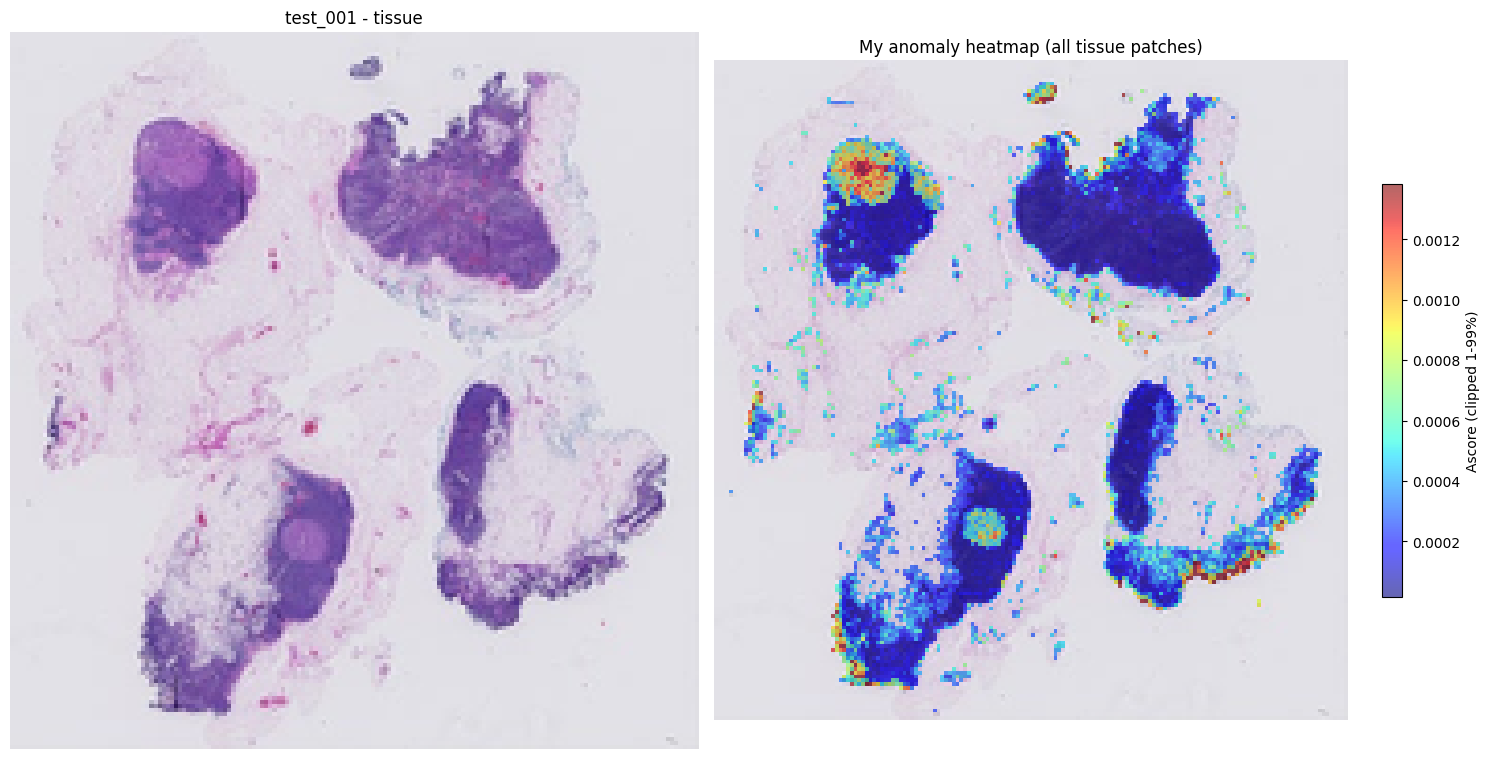

Saved: /content/ICCV2025_Ano-NAViLa/test_001_FULL_heatmap.png
Scored cells: 6634 | vmin=1.599e-05 vmax=1.385e-03


In [18]:
# ============================================================
# Heatmap from MY scores
# Reuses : WSI_PATH, FULL_SCORES_CSV
# Output : test_001_FULL_heatmap.png
# ============================================================
import os
import numpy as np
import pandas as pd
import openslide
import matplotlib.pyplot as plt

SCALE   = 512   # one heatmap cell per 512 px patch
OUT_PNG = os.path.join(REPO_DIR, "test_001_FULL_heatmap.png")

slide  = openslide.OpenSlide(WSI_PATH)
W0, H0 = slide.dimensions
gw, gh = W0 // SCALE, H0 // SCALE

df   = pd.read_csv(FULL_SCORES_CSV)
grid = np.full((gh, gw), np.nan, dtype=np.float32)
for _, r in df.iterrows():
    parts  = str(r["patch_name"]).replace(".png", "").split("_")
    x, y   = int(parts[-3]), int(parts[-2])
    gx, gy = x // SCALE, y // SCALE
    if 0 <= gx < gw and 0 <= gy < gh:
        grid[gy, gx] = r["Ascore"]

thumb = slide.get_thumbnail((gw, gh)).resize((gw, gh))
thumb = np.asarray(thumb)


vals       = grid[~np.isnan(grid)]
vmin, vmax = np.percentile(vals, 1), np.percentile(vals, 99)
masked     = np.ma.masked_invalid(grid)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
axes[0].imshow(thumb); axes[0].set_title("test_001 - tissue"); axes[0].axis("off")

axes[1].imshow(thumb)
im = axes[1].imshow(masked, cmap="jet", alpha=0.6, vmin=vmin, vmax=vmax,
                    interpolation="nearest")
axes[1].set_title("My anomaly heatmap (all tissue patches)"); axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.03, label="Ascore (clipped 1-99%)")

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_PNG}")
print(f"Scored cells: {len(vals)} | vmin={vmin:.3e} vmax={vmax:.3e}")